In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Load and explore the Egencia booking data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('Egencia_Analytics_Cleaned.csv', encoding='ascii')

# Basic data exploration
print("Dataset shape:", df.shape)
print("\
Column names and types:")
print(df.dtypes)
print("\
First few rows:")
print(df.head())

Dataset shape: (299974, 14)
Column names and types:
BOOKING_ID                int64
BOOKING_TYPE_NAME        object
PRODUCT_NAME             object
PLATFORM                 object
CUSTOMER_ID               int64
TRAVELER_ID               int64
BOOKING_DATE             object
TRAVEL_START             object
TRAVEL_END               object
INVOICE_DATE             object
ONLINE_PURCHASE_FLAG       bool
BOOKING_AMOUNT          float64
SAVINGS_AMOUNT          float64
TRANSACTION_COUNT         int64
dtype: object
First few rows:
   BOOKING_ID BOOKING_TYPE_NAME PRODUCT_NAME PLATFORM  CUSTOMER_ID  \
0   159585350           Reserve          Car  Desktop            0   
1   128623600            Cancel          Car  Desktop            0   
2    16125082           Reserve          Car   Mobile            0   
3   129001472           Reserve          Car  Desktop            0   
4    64792032           Reserve          Car  Desktop            0   

   TRAVELER_ID BOOKING_DATE TRAVEL_START  TRAVEL_

In [2]:
# Convert date columns to datetime and prepare data for time series analysis
df['BOOKING_DATE'] = pd.to_datetime(df['BOOKING_DATE'])
df['TRAVEL_START'] = pd.to_datetime(df['TRAVEL_START'])
df['TRAVEL_END'] = pd.to_datetime(df['TRAVEL_END'])

# Extract year-month for aggregation
df['booking_year_month'] = df['BOOKING_DATE'].dt.to_period('M')
df['booking_year'] = df['BOOKING_DATE'].dt.year
df['booking_quarter'] = df['BOOKING_DATE'].dt.to_period('Q')

# Check data range
print("Date range:", df['BOOKING_DATE'].min(), "to", df['BOOKING_DATE'].max())
print("Unique booking types:", df['BOOKING_TYPE_NAME'].unique())
print("Unique products:", df['PRODUCT_NAME'].unique())
print("Unique platforms:", df['PLATFORM'].unique())

Date range: 2018-01-01 00:00:00 to 2018-12-31 00:00:00
Unique booking types: ['Reserve' 'Cancel' 'Purchase' 'Refund' 'Exchange' 'Partial Refund' 'Void']
Unique products: ['Car' 'Hotel' 'Air']
Unique platforms: ['Desktop' 'Mobile']


In [3]:
# Analyze monthly trends in booking value and transaction count
monthly_trends = df.groupby('booking_year_month').agg({
    'BOOKING_AMOUNT': ['sum', 'count'],
    'TRANSACTION_COUNT': 'sum'
}).round(2)

monthly_trends.columns = ['Total_Booking_Value', 'Number_of_Bookings', 'Total_Transactions']
monthly_trends = monthly_trends.reset_index()
monthly_trends['booking_year_month'] = monthly_trends['booking_year_month'].astype(str)

print("Monthly booking trends:")
print(monthly_trends)

Monthly booking trends:
   booking_year_month  Total_Booking_Value  Number_of_Bookings  \
0             2018-01          34498410.18               27991   
1             2018-02          33509844.03               25836   
2             2018-03          40459058.27               31701   
3             2018-04         -66719840.76               26485   
4             2018-05          36671089.57               27873   
5             2018-06          37884843.54               29640   
6             2018-07          25622020.18               19365   
7             2018-08          45224253.24               14681   
8             2018-09          33145167.30               25627   
9             2018-10          39276124.09               28954   
10            2018-11          33399620.81               26406   
11            2018-12          20192643.99               15415   

    Total_Transactions  
0               126350  
1               115154  
2               142850  
3               1

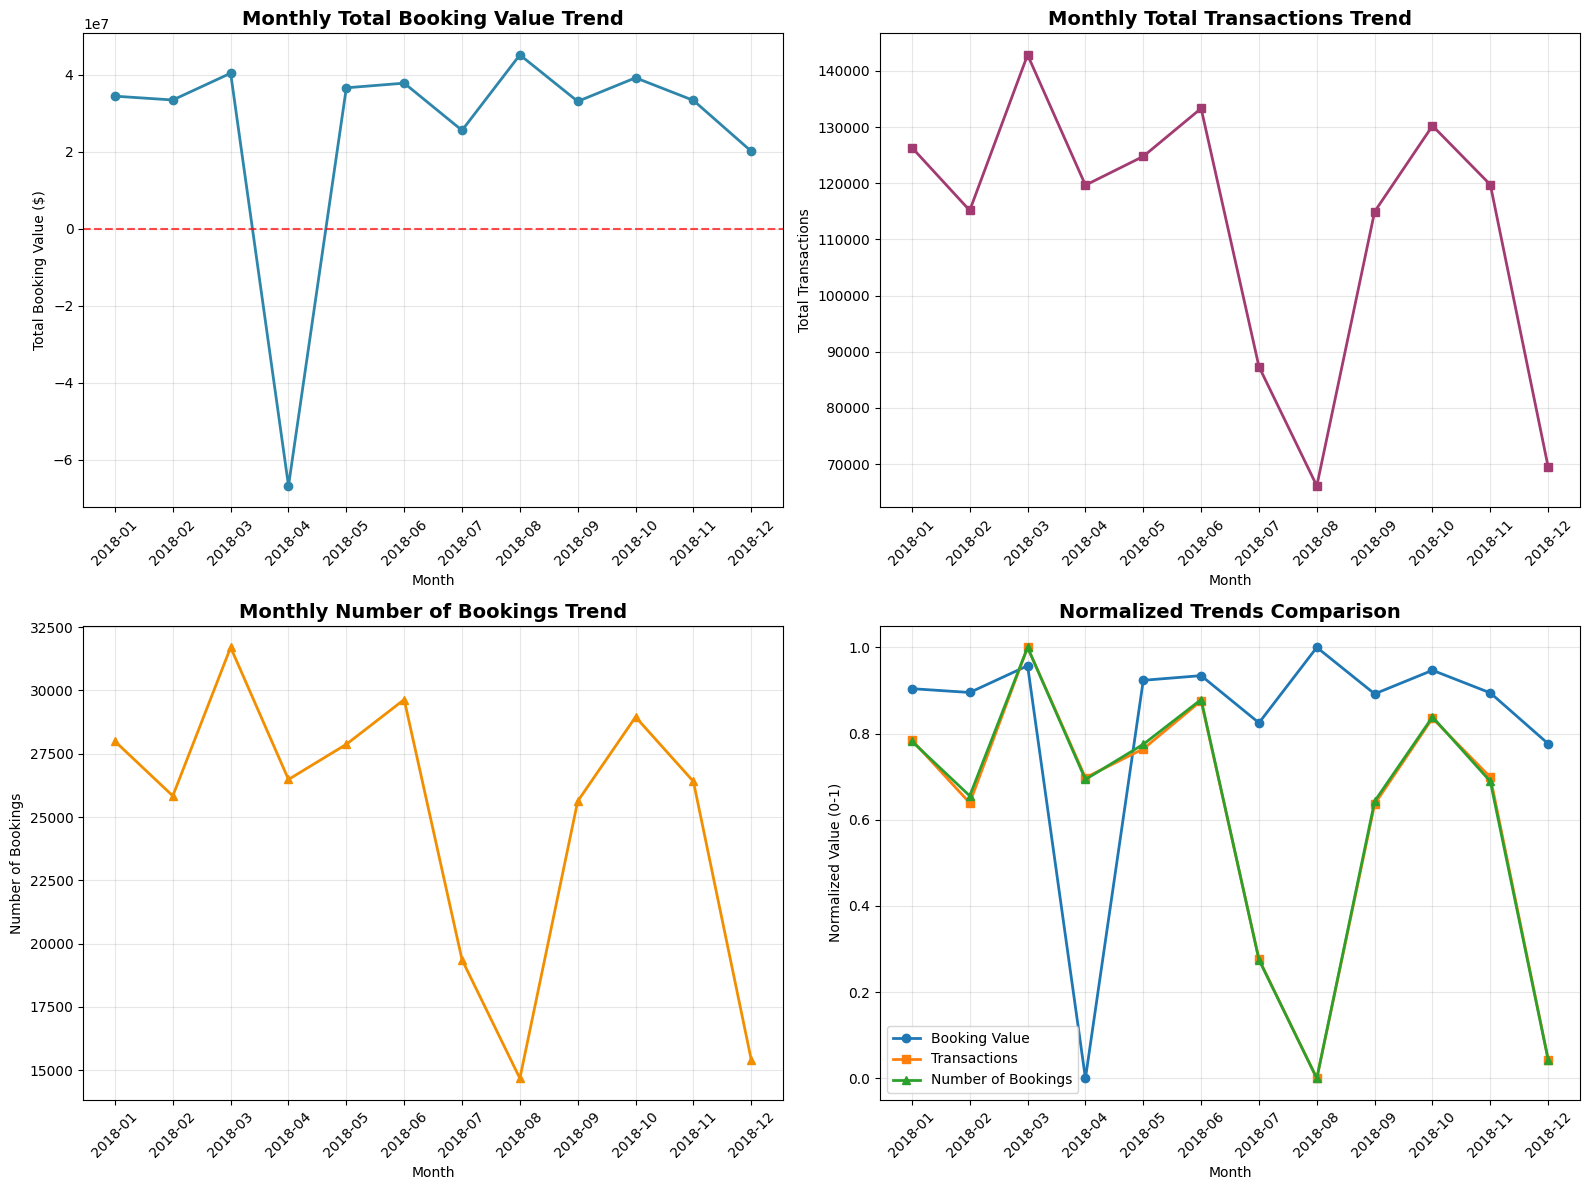

In [4]:
# Create comprehensive visualizations for booking trends analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Monthly Total Booking Value Trend
axes[0,0].plot(monthly_trends['booking_year_month'], monthly_trends['Total_Booking_Value'], 
               marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0,0].set_title('Monthly Total Booking Value Trend', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Total Booking Value ($)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.7)

# 2. Monthly Transaction Count Trend
axes[0,1].plot(monthly_trends['booking_year_month'], monthly_trends['Total_Transactions'], 
               marker='s', linewidth=2, markersize=6, color='#A23B72')
axes[0,1].set_title('Monthly Total Transactions Trend', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Total Transactions')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# 3. Number of Bookings Trend
axes[1,0].plot(monthly_trends['booking_year_month'], monthly_trends['Number_of_Bookings'], 
               marker='^', linewidth=2, markersize=6, color='#F18F01')
axes[1,0].set_title('Monthly Number of Bookings Trend', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Number of Bookings')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# 4. Combined normalized trends
norm_booking_value = (monthly_trends['Total_Booking_Value'] - monthly_trends['Total_Booking_Value'].min()) / (monthly_trends['Total_Booking_Value'].max() - monthly_trends['Total_Booking_Value'].min())
norm_transactions = (monthly_trends['Total_Transactions'] - monthly_trends['Total_Transactions'].min()) / (monthly_trends['Total_Transactions'].max() - monthly_trends['Total_Transactions'].min())
norm_bookings = (monthly_trends['Number_of_Bookings'] - monthly_trends['Number_of_Bookings'].min()) / (monthly_trends['Number_of_Bookings'].max() - monthly_trends['Number_of_Bookings'].min())

axes[1,1].plot(monthly_trends['booking_year_month'], norm_booking_value, marker='o', label='Booking Value', linewidth=2)
axes[1,1].plot(monthly_trends['booking_year_month'], norm_transactions, marker='s', label='Transactions', linewidth=2)
axes[1,1].plot(monthly_trends['booking_year_month'], norm_bookings, marker='^', label='Number of Bookings', linewidth=2)
axes[1,1].set_title('Normalized Trends Comparison', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Normalized Value (0-1)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Analyze booking types to identify causes of decline
booking_type_monthly = df.groupby(['booking_year_month', 'BOOKING_TYPE_NAME']).agg({
    'BOOKING_AMOUNT': 'sum',
    'TRANSACTION_COUNT': 'sum'
}).reset_index()

# Pivot for better visualization
booking_type_pivot = booking_type_monthly.pivot(index='booking_year_month', 
                                               columns='BOOKING_TYPE_NAME', 
                                               values='BOOKING_AMOUNT').fillna(0)

print("Booking amounts by type and month:")
print(booking_type_pivot.round(2))

Booking amounts by type and month:
BOOKING_TYPE_NAME       Cancel   Exchange  Partial Refund     Purchase  \
booking_year_month                                                       
2018-01            -1179905.32  470320.27      -966052.10  32958567.84   
2018-02             -877393.44  487179.40      -760040.40  32125754.68   
2018-03            -1389665.03  851362.72     -1062941.41  39203314.50   
2018-04            -1061212.15  535842.31      -949703.01  32717690.04   
2018-05            -1359628.52  590748.73      -628253.50  34236013.89   
2018-06            -1388418.07  585469.45     -1204675.65  36493731.70   
2018-07             -991034.08  604006.32     -1112925.69  25859088.81   
2018-08             -594556.78  279819.14      -375009.01  44507667.16   
2018-09             -990524.19  653319.67      -870475.65  31941865.42   
2018-10            -1127179.06  650297.25      -825091.09  38089165.89   
2018-11            -1172774.41  616704.55      -620500.83  31718044.80   
201

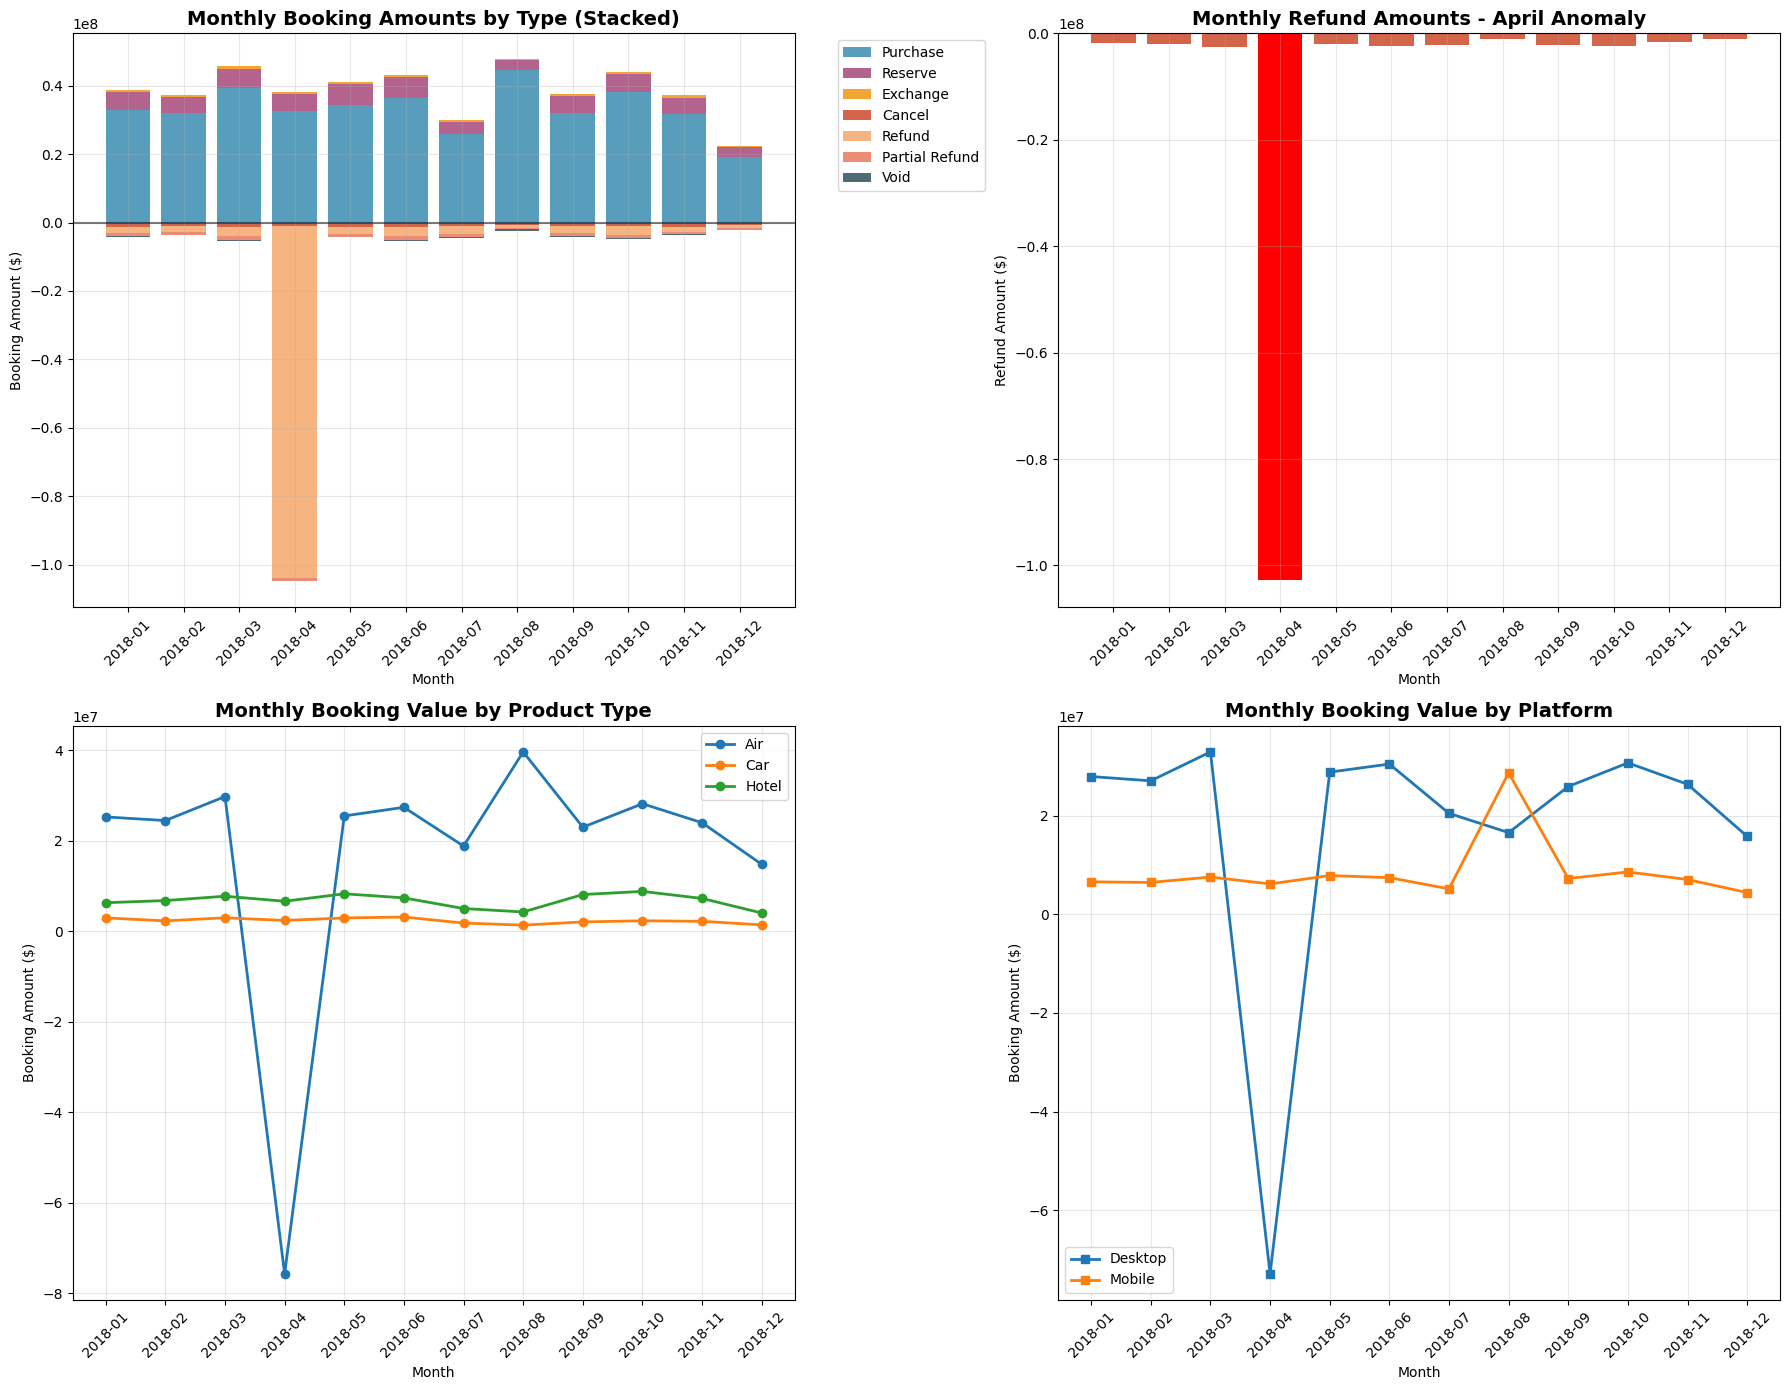

In [6]:
# Create comprehensive visualizations for booking type analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Stacked bar chart showing booking amounts by type over time
booking_type_pivot_plot = booking_type_pivot.copy()
booking_type_pivot_plot.index = booking_type_pivot_plot.index.astype(str)

# Separate positive and negative values for better visualization
positive_cols = ['Purchase', 'Reserve', 'Exchange']
negative_cols = ['Cancel', 'Refund', 'Partial Refund', 'Void']

# Plot positive booking types
bottom_pos = np.zeros(len(booking_type_pivot_plot))
colors_pos = ['#2E86AB', '#A23B72', '#F18F01']
for i, col in enumerate(positive_cols):
    if col in booking_type_pivot_plot.columns:
        axes[0,0].bar(booking_type_pivot_plot.index, booking_type_pivot_plot[col], 
                     bottom=bottom_pos, label=col, color=colors_pos[i], alpha=0.8)
        bottom_pos += booking_type_pivot_plot[col]

# Plot negative booking types
bottom_neg = np.zeros(len(booking_type_pivot_plot))
colors_neg = ['#C73E1D', '#F4A261', '#E76F51', '#264653']
for i, col in enumerate(negative_cols):
    if col in booking_type_pivot_plot.columns:
        axes[0,0].bar(booking_type_pivot_plot.index, booking_type_pivot_plot[col], 
                     bottom=bottom_neg, label=col, color=colors_neg[i], alpha=0.8)
        bottom_neg += booking_type_pivot_plot[col]

axes[0,0].set_title('Monthly Booking Amounts by Type (Stacked)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Booking Amount ($)')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].axhline(y=0, color='black', linestyle='-', alpha=0.5)

# 2. Focus on major negative impact - Refunds in April
refund_data = booking_type_pivot['Refund'].reset_index()
refund_data['booking_year_month'] = refund_data['booking_year_month'].astype(str)
axes[0,1].bar(refund_data['booking_year_month'], refund_data['Refund'], 
              color='#C73E1D', alpha=0.8)
axes[0,1].set_title('Monthly Refund Amounts - April Anomaly', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Refund Amount ($)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)
# Highlight April
axes[0,1].bar('2018-04', refund_data[refund_data['booking_year_month'] == '2018-04']['Refund'].iloc[0], 
              color='red', alpha=1.0)

# 3. Product-wise analysis
product_monthly = df.groupby(['booking_year_month', 'PRODUCT_NAME']).agg({
    'BOOKING_AMOUNT': 'sum'
}).reset_index()
product_pivot = product_monthly.pivot(index='booking_year_month', 
                                     columns='PRODUCT_NAME', 
                                     values='BOOKING_AMOUNT').fillna(0)
product_pivot.index = product_pivot.index.astype(str)

for col in product_pivot.columns:
    axes[1,0].plot(product_pivot.index, product_pivot[col], 
                   marker='o', linewidth=2, label=col)
axes[1,0].set_title('Monthly Booking Value by Product Type', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Booking Amount ($)')
axes[1,0].legend()
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# 4. Platform analysis
platform_monthly = df.groupby(['booking_year_month', 'PLATFORM']).agg({
    'BOOKING_AMOUNT': 'sum',
    'TRANSACTION_COUNT': 'sum'
}).reset_index()
platform_pivot = platform_monthly.pivot(index='booking_year_month', 
                                        columns='PLATFORM', 
                                        values='BOOKING_AMOUNT').fillna(0)
platform_pivot.index = platform_pivot.index.astype(str)

for col in platform_pivot.columns:
    axes[1,1].plot(platform_pivot.index, platform_pivot[col], 
                   marker='s', linewidth=2, label=col)
axes[1,1].set_title('Monthly Booking Value by Platform', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Booking Amount ($)')
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Deep dive into April 2018 anomaly - the major cause of decline
april_data = df[df['booking_year_month'] == '2018-04']

print("April 2018 Analysis:")
print("Total booking amount in April:", april_data['BOOKING_AMOUNT'].sum())
print("Number of bookings in April:", len(april_data))
print("\
Breakdown by booking type in April:")
april_breakdown = april_data.groupby('BOOKING_TYPE_NAME').agg({
    'BOOKING_AMOUNT': ['sum', 'count'],
    'TRANSACTION_COUNT': 'sum'
}).round(2)
april_breakdown.columns = ['Total_Amount', 'Count', 'Transactions']
print(april_breakdown)

print("\
Largest refunds in April:")
april_refunds = april_data[april_data['BOOKING_TYPE_NAME'] == 'Refund'].sort_values('BOOKING_AMOUNT')
print(april_refunds[['BOOKING_ID', 'PRODUCT_NAME', 'BOOKING_AMOUNT', 'BOOKING_DATE']].head(10))

April 2018 Analysis:
Total booking amount in April: -66719840.760000005
Number of bookings in April: 26485
Breakdown by booking type in April:
                   Total_Amount  Count  Transactions
BOOKING_TYPE_NAME                                   
Cancel            -1.061212e+06   1307          5796
Exchange           5.358423e+05    850          3772
Partial Refund    -9.497030e+05    493          2124
Purchase           3.271769e+07  16036         72608
Refund            -1.027485e+08   1334          6004
Reserve            4.854427e+06   6441         29264
Void              -6.837859e+04     24            87
Largest refunds in April:
        BOOKING_ID PRODUCT_NAME  BOOKING_AMOUNT BOOKING_DATE
1179    1973157021          Air   -1.000213e+08   2018-04-23
289245  2064063290          Air   -6.721956e+04   2018-04-10
225567  1250611074          Air   -4.524728e+04   2018-04-20
18788   1450337378          Air   -4.474050e+04   2018-04-17
19223   2071910550          Air   -4.350216e+04  

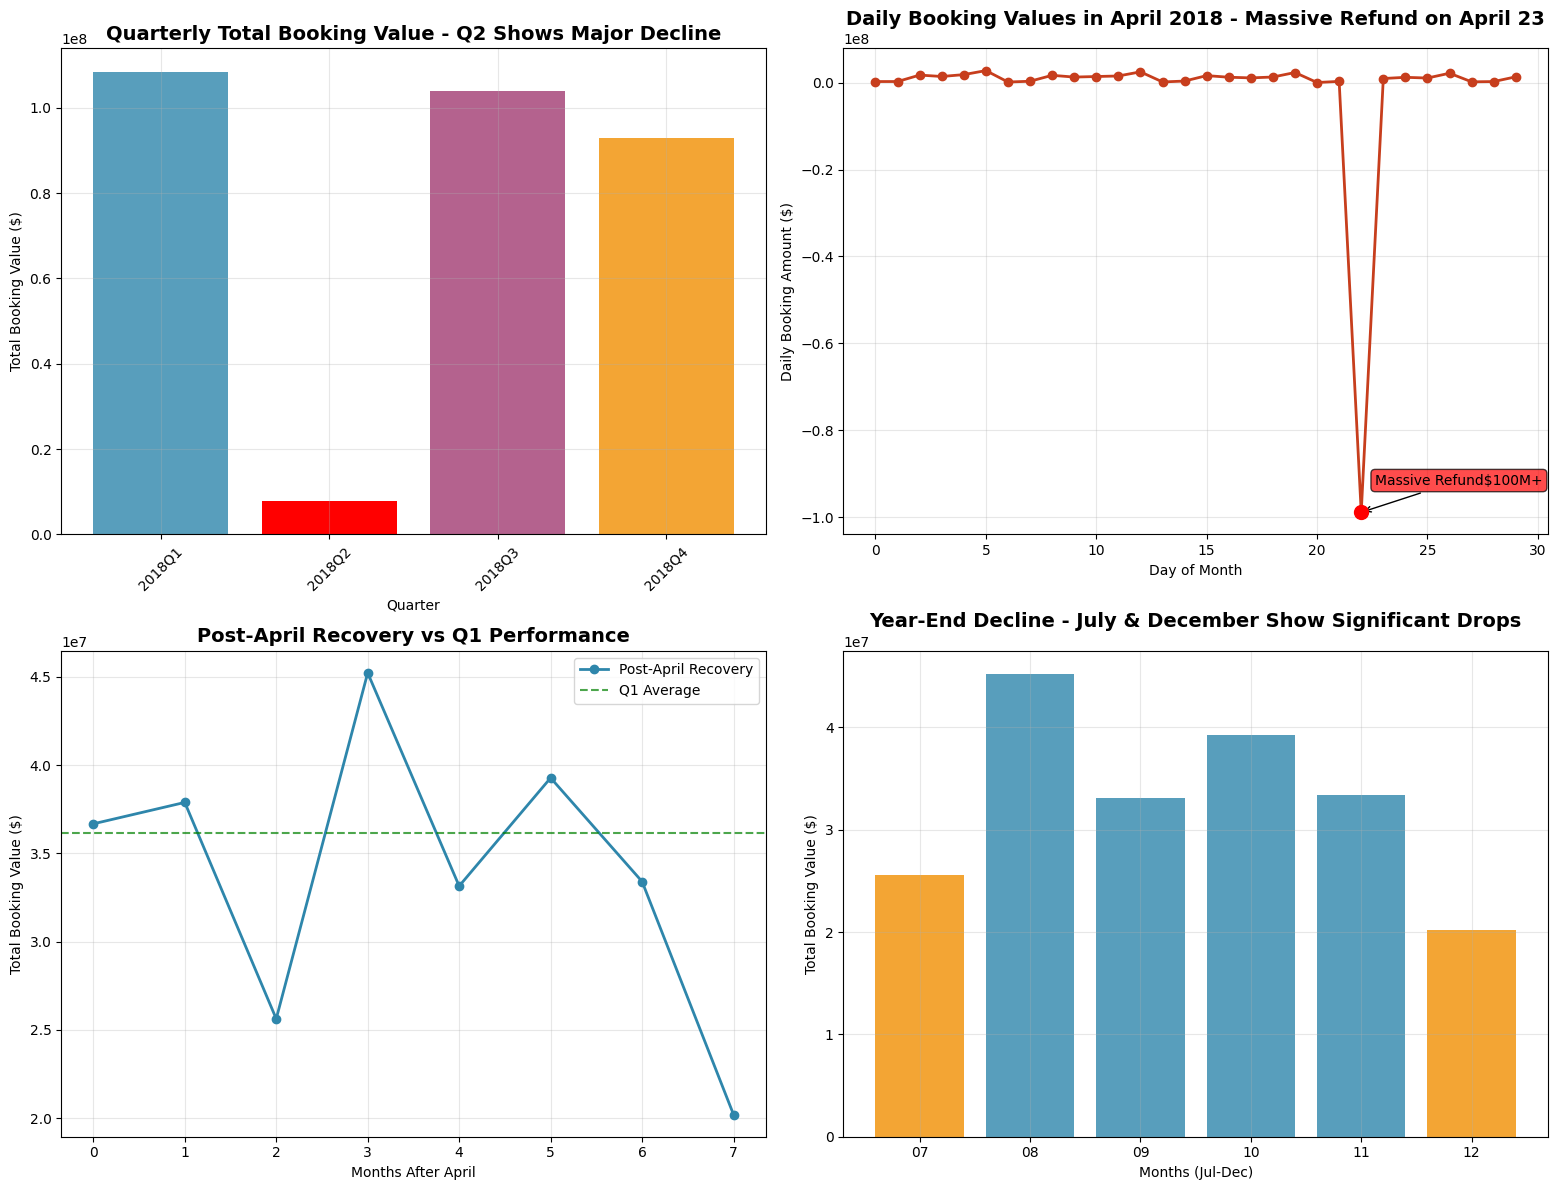

In [8]:
# Fix the plotting error by properly handling date formats
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Quarterly comparison to show overall decline trend
quarterly_data = df.groupby('booking_quarter').agg({
    'BOOKING_AMOUNT': 'sum',
    'TRANSACTION_COUNT': 'sum'
}).reset_index()
quarterly_data['booking_quarter'] = quarterly_data['booking_quarter'].astype(str)

axes[0,0].bar(quarterly_data['booking_quarter'], quarterly_data['BOOKING_AMOUNT'], 
              color=['#2E86AB', '#C73E1D', '#A23B72', '#F18F01'], alpha=0.8)
axes[0,0].set_title('Quarterly Total Booking Value - Q2 Shows Major Decline', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Quarter')
axes[0,0].set_ylabel('Total Booking Value ($)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)
# Highlight Q2 (which includes April)
q2_value = quarterly_data[quarterly_data['booking_quarter'] == '2018Q2']['BOOKING_AMOUNT'].iloc[0]
axes[0,0].bar('2018Q2', q2_value, color='red', alpha=1.0)

# 2. Daily trend in April to pinpoint the exact issue
april_daily = april_data.groupby(april_data['BOOKING_DATE'].dt.date).agg({
    'BOOKING_AMOUNT': 'sum'
}).reset_index()

axes[0,1].plot(range(len(april_daily)), april_daily['BOOKING_AMOUNT'], 
               marker='o', linewidth=2, color='#C73E1D')
axes[0,1].set_title('Daily Booking Values in April 2018 - Massive Refund on April 23', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Day of Month')
axes[0,1].set_ylabel('Daily Booking Amount ($)')
axes[0,1].grid(True, alpha=0.3)

# Find April 23rd index and highlight it
april_23_idx = april_daily[april_daily['BOOKING_DATE'] == pd.to_datetime('2018-04-23').date()].index
if len(april_23_idx) > 0:
    idx = april_23_idx[0]
    april_23_value = april_daily.iloc[idx]['BOOKING_AMOUNT']
    axes[0,1].scatter([idx], [april_23_value], color='red', s=100, zorder=5)
    axes[0,1].annotate('Massive Refund\
$100M+', xy=(idx, april_23_value), 
                       xytext=(10, 20), textcoords='offset points', 
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7),
                       arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# 3. Recovery analysis - months after April
recovery_months = ['2018-05', '2018-06', '2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12']
recovery_data = monthly_trends[monthly_trends['booking_year_month'].isin(recovery_months)]
q1_avg = monthly_trends[monthly_trends['booking_year_month'].isin(['2018-01', '2018-02', '2018-03'])]['Total_Booking_Value'].mean()

axes[1,0].plot(range(len(recovery_data)), recovery_data['Total_Booking_Value'], 
               marker='o', linewidth=2, color='#2E86AB', label='Post-April Recovery')
axes[1,0].axhline(y=q1_avg, color='green', linestyle='--', alpha=0.7, label='Q1 Average')
axes[1,0].set_title('Post-April Recovery vs Q1 Performance', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Months After April')
axes[1,0].set_ylabel('Total Booking Value ($)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Year-end decline analysis
year_end_months = ['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12']
year_end_data = monthly_trends[monthly_trends['booking_year_month'].isin(year_end_months)]

colors = ['#F18F01' if x in ['2018-07', '2018-12'] else '#2E86AB' for x in year_end_data['booking_year_month']]
axes[1,1].bar(range(len(year_end_data)), year_end_data['Total_Booking_Value'], 
              color=colors, alpha=0.8)
axes[1,1].set_title('Year-End Decline - July & December Show Significant Drops', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Months (Jul-Dec)')
axes[1,1].set_ylabel('Total Booking Value ($)')
axes[1,1].set_xticks(range(len(year_end_data)))
axes[1,1].set_xticklabels([m.split('-')[1] for m in year_end_data['booking_year_month']])
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Create summary insights and key findings
print("=== KEY FINDINGS: AMEX GBT Booking Decline Analysis ===")
print()

# Calculate key metrics
total_2018 = df['BOOKING_AMOUNT'].sum()
q1_total = monthly_trends[monthly_trends['booking_year_month'].isin(['2018-01', '2018-02', '2018-03'])]['Total_Booking_Value'].sum()
q2_total = monthly_trends[monthly_trends['booking_year_month'].isin(['2018-04', '2018-05', '2018-06'])]['Total_Booking_Value'].sum()
april_impact = april_data['BOOKING_AMOUNT'].sum()
mega_refund = april_data[april_data['BOOKING_ID'] == 1973157021]['BOOKING_AMOUNT'].iloc[0]

print("1. OVERALL IMPACT:")
print("   • Total 2018 booking value: $" + "{:,.2f}".format(total_2018))
print("   • Q1 2018 total: $" + "{:,.2f}".format(q1_total))
print("   • Q2 2018 total: $" + "{:,.2f}".format(q2_total))
print("   • Q1 to Q2 decline: $" + "{:,.2f}".format(q1_total - q2_total) + " (" + "{:.1f}%".format(((q1_total - q2_total) / q1_total) * 100) + ")")
print()

print("2. ROOT CAUSE - APRIL 2018 ANOMALY:")
print("   • April 2018 net booking value: $" + "{:,.2f}".format(april_impact))
print("   • Single massive refund on April 23: $" + "{:,.2f}".format(mega_refund))
print("   • This single refund represents " + "{:.1f}%".format((abs(mega_refund) / abs(april_impact)) * 100) + " of April's negative impact")
print("   • Booking ID: 1973157021 (Air travel product)")
print()

print("3. SECONDARY DECLINE FACTORS:")
july_dec_avg = monthly_trends[monthly_trends['booking_year_month'].isin(['2018-07', '2018-12'])]['Total_Booking_Value'].mean()
other_months_avg = monthly_trends[~monthly_trends['booking_year_month'].isin(['2018-04', '2018-07', '2018-12'])]['Total_Booking_Value'].mean()
print("   • July & December show significant underperformance")
print("   • July/December average: $" + "{:,.2f}".format(july_dec_avg))
print("   • Other months average: $" + "{:,.2f}".format(other_months_avg))
print("   • Seasonal decline impact: $" + "{:,.2f}".format(other_months_avg - july_dec_avg))
print()

print("4. PRODUCT & PLATFORM INSIGHTS:")
air_total = df[df['PRODUCT_NAME'] == 'Air']['BOOKING_AMOUNT'].sum()
hotel_total = df[df['PRODUCT_NAME'] == 'Hotel']['BOOKING_AMOUNT'].sum()
car_total = df[df['PRODUCT_NAME'] == 'Car']['BOOKING_AMOUNT'].sum()
print("   • Air travel bookings: $" + "{:,.2f}".format(air_total) + " (most affected by mega-refund)")
print("   • Hotel bookings: $" + "{:,.2f}".format(hotel_total))
print("   • Car rental bookings: $" + "{:,.2f}".format(car_total))

desktop_total = df[df['PLATFORM'] == 'Desktop']['BOOKING_AMOUNT'].sum()
mobile_total = df[df['PLATFORM'] == 'Mobile']['BOOKING_AMOUNT'].sum()
print("   • Desktop platform: $" + "{:,.2f}".format(desktop_total))
print("   • Mobile platform: $" + "{:,.2f}".format(mobile_total))
print()

print("5. RECOMMENDATIONS:")
print("   • Investigate the $100M+ refund on April 23, 2018 (Booking ID: 1973157021)")
print("   • Review refund policies and approval processes for large transactions")
print("   • Analyze seasonal patterns causing July/December declines")
print("   • Implement early warning systems for unusual refund activities")
print("   • Focus recovery efforts on air travel segment which was most impacted")

=== KEY FINDINGS: AMEX GBT Booking Decline Analysis ===

1. OVERALL IMPACT:
   • Total 2018 booking value: $313,163,234.44
   • Q1 2018 total: $108,467,312.48
   • Q2 2018 total: $7,836,092.35
   • Q1 to Q2 decline: $100,631,220.13 (92.8%)

2. ROOT CAUSE - APRIL 2018 ANOMALY:
   • April 2018 net booking value: $-66,719,840.76
   • Single massive refund on April 23: $-100,021,332.20
   • This single refund represents 149.9% of April's negative impact
   • Booking ID: 1973157021 (Air travel product)

3. SECONDARY DECLINE FACTORS:
   • July & December show significant underperformance
   • July/December average: $22,907,332.09
   • Other months average: $37,118,712.34
   • Seasonal decline impact: $14,211,380.25

4. PRODUCT & PLATFORM INSIGHTS:
   • Air travel bookings: $204,956,667.50 (most affected by mega-refund)
   • Hotel bookings: $80,493,031.40
   • Car rental bookings: $27,713,535.54
   • Desktop platform: $210,038,922.45
   • Mobile platform: $103,124,311.99

5. RECOMMENDATIONS:


In [11]:
pip install scikit-learn

  Using cached scikit_learn-1.7.0-cp313-cp313-win_amd64.whl.metadata (14 kB)
  Using cached scipy-1.16.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.0-cp313-cp313-win_amd64.whl (10.7 MB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
Using cached scipy-1.16.0-cp313-cp313-win_amd64.whl (38.4 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- -----------------

In [12]:
# Feature engineering for machine learning analysis
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Create comprehensive feature set
df_ml = df.copy()

# Time-based features
df_ml['booking_day_of_week'] = df_ml['BOOKING_DATE'].dt.dayofweek
df_ml['booking_month'] = df_ml['BOOKING_DATE'].dt.month
df_ml['booking_quarter'] = df_ml['BOOKING_DATE'].dt.quarter
df_ml['booking_day_of_year'] = df_ml['BOOKING_DATE'].dt.dayofyear
df_ml['is_weekend'] = (df_ml['booking_day_of_week'] >= 5).astype(int)

# Travel duration features
df_ml['travel_duration'] = (df_ml['TRAVEL_END'] - df_ml['TRAVEL_START']).dt.days
df_ml['booking_to_travel_lead_time'] = (df_ml['TRAVEL_START'] - df_ml['BOOKING_DATE']).dt.days

# Booking behavior features
df_ml['avg_transaction_value'] = df_ml['BOOKING_AMOUNT'] / (df_ml['TRANSACTION_COUNT'] + 1)  # +1 to avoid division by zero
df_ml['is_negative_booking'] = (df_ml['BOOKING_AMOUNT'] < 0).astype(int)
df_ml['is_high_value'] = (df_ml['BOOKING_AMOUNT'] > df_ml['BOOKING_AMOUNT'].quantile(0.9)).astype(int)
df_ml['is_refund_related'] = df_ml['BOOKING_TYPE_NAME'].isin(['Refund', 'Cancel', 'Partial Refund']).astype(int)

# Customer behavior features
customer_stats = df_ml.groupby('CUSTOMER_ID').agg({
    'BOOKING_AMOUNT': ['count', 'mean', 'std'],
    'TRANSACTION_COUNT': 'sum'
}).round(2)
customer_stats.columns = ['customer_booking_frequency', 'customer_avg_booking', 'customer_booking_volatility', 'customer_total_transactions']
customer_stats['customer_booking_volatility'] = customer_stats['customer_booking_volatility'].fillna(0)
df_ml = df_ml.merge(customer_stats, left_on='CUSTOMER_ID', right_index=True, how='left')

# Traveler behavior features
traveler_stats = df_ml.groupby('TRAVELER_ID').agg({
    'BOOKING_AMOUNT': ['count', 'mean'],
    'TRAVEL_START': 'nunique'
}).round(2)
traveler_stats.columns = ['traveler_booking_frequency', 'traveler_avg_booking', 'traveler_unique_trips']
df_ml = df_ml.merge(traveler_stats, left_on='TRAVELER_ID', right_index=True, how='left')

print("Feature engineering completed. New features created:")
new_features = ['booking_day_of_week', 'booking_month', 'booking_quarter', 'booking_day_of_year', 
                'is_weekend', 'travel_duration', 'booking_to_travel_lead_time', 'avg_transaction_value',
                'is_negative_booking', 'is_high_value', 'is_refund_related', 'customer_booking_frequency',
                'customer_avg_booking', 'customer_booking_volatility', 'customer_total_transactions',
                'traveler_booking_frequency', 'traveler_avg_booking', 'traveler_unique_trips']
for feature in new_features:
    print("  •", feature)
print("Total features available:", len(new_features))

Feature engineering completed. New features created:
  • booking_day_of_week
  • booking_month
  • booking_quarter
  • booking_day_of_year
  • is_weekend
  • travel_duration
  • booking_to_travel_lead_time
  • avg_transaction_value
  • is_negative_booking
  • is_high_value
  • is_refund_related
  • customer_booking_frequency
  • customer_avg_booking
  • customer_booking_volatility
  • customer_total_transactions
  • traveler_booking_frequency
  • traveler_avg_booking
  • traveler_unique_trips
Total features available: 18
